Tamanho da imagem :  (647, 647)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


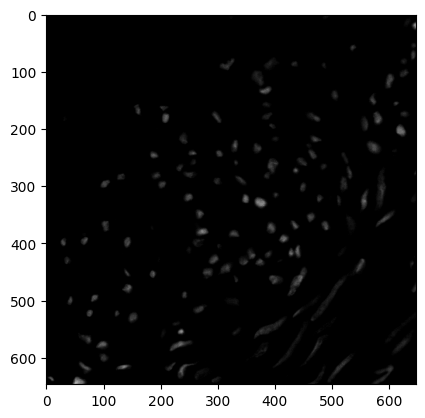

In [12]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math


img = cv2.imread("im_cells.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray', vmin=0, vmax=255);

print('Tamanho da imagem : ',img.shape)
print(img)




linhas = img.shape[0]
colunas = img.shape[1];



(np.float64(-0.5), np.float64(646.5), np.float64(646.5), np.float64(-0.5))

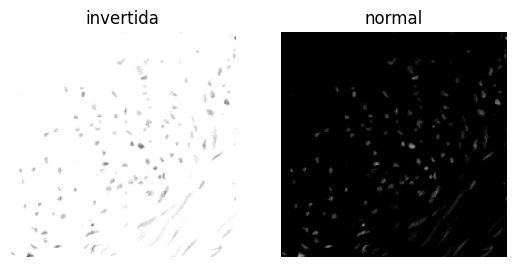

In [2]:
def inverter_cores(img,linhas,colunas):
    for i in range(0,linhas):
        for j in range(0,colunas):
            img[i,j] = 255 - img[i,j]
    return img

invertida = inverter_cores(img.copy(),linhas,colunas)
plt.subplot(1,2,1)
plt.imshow(invertida, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title('invertida')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title('normal')
plt.axis('off')


In [13]:
def log2(img,linhas,colunas):
    for i in range(0, linhas-1):
        for j in range(0, colunas-1):
            if img[i,j] > 0:
                img[i,j] = math.pow(math.floor(math.log2(img[i,j])),2)

    return img

(np.float64(-0.5), np.float64(646.5), np.float64(646.5), np.float64(-0.5))

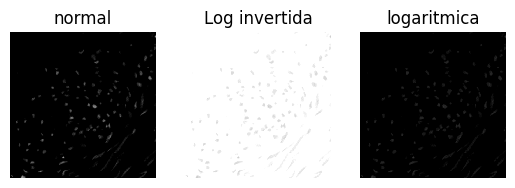

In [14]:
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title('normal')
plt.axis('off')

plt.subplot(1,3,2)
logaritmicaInvertida = inverter_cores(log2(img.copy(),linhas,colunas),linhas,colunas)
plt.imshow(logaritmicaInvertida, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title('Log invertida')
plt.axis('off')

plt.subplot(1,3,3)
logaritmica = log2(img.copy(),linhas,colunas)
plt.imshow(logaritmica, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title('logaritmica')
plt.axis('off')

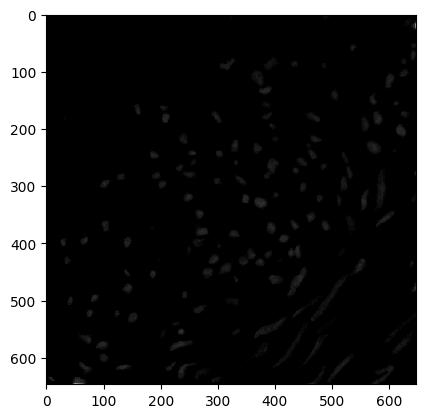

In [15]:
plt.imshow(logaritmica, cmap='gray', vmin=0, vmax=255, interpolation='nearest')

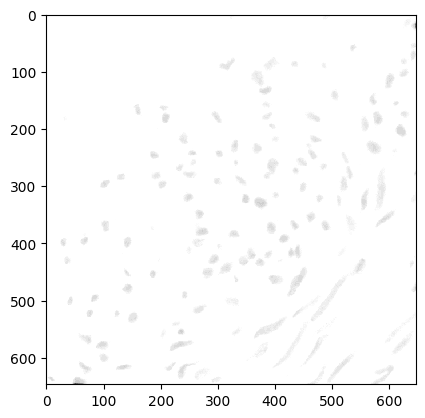

In [16]:
plt.imshow(logaritmicaInvertida, cmap='gray', vmin=0, vmax=255, interpolation='nearest')

Tamanho da imagem :  (291, 240)
[[107 108 107 ...  84  83  83]
 [109 106 108 ...  84  84  86]
 [107 106 110 ...  84  83  83]
 ...
 [ 97  99 101 ...  82  82  83]
 [ 99  98  98 ...  84  84  86]
 [101  99  99 ...  97  97  97]]


C:\Users\leand\AppData\Local\Temp\ipykernel_33348\4226758683.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(),256,[0,256], color = 'r')


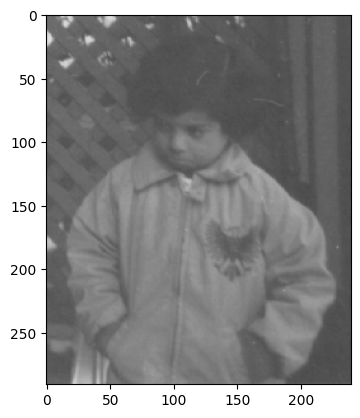

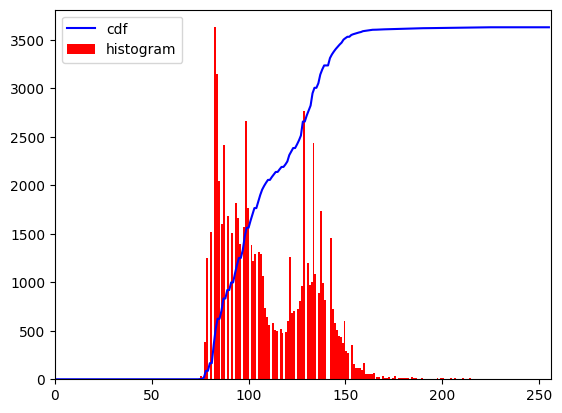

In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math


img = cv2.imread("pout.tif", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray', vmin=0, vmax=255);

print('Tamanho da imagem : ',img.shape)
print(img)


 
hist,bins = np.histogram(img.flatten(),256,[0,256])
cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max()) / cdf.max()

plt.figure()

plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')
plt.show()



linhas = img.shape[0]
colunas = img.shape[1]



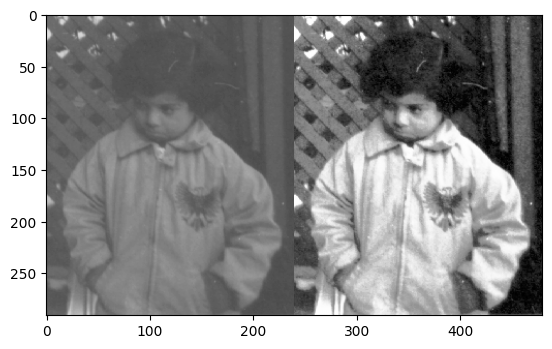

In [9]:
equ = cv2.equalizeHist(img)
res = np.hstack((img,equ)) 
plt.imshow(res, cmap='gray', vmin=0, vmax=255);

(np.float64(-0.5), np.float64(646.5), np.float64(646.5), np.float64(-0.5))

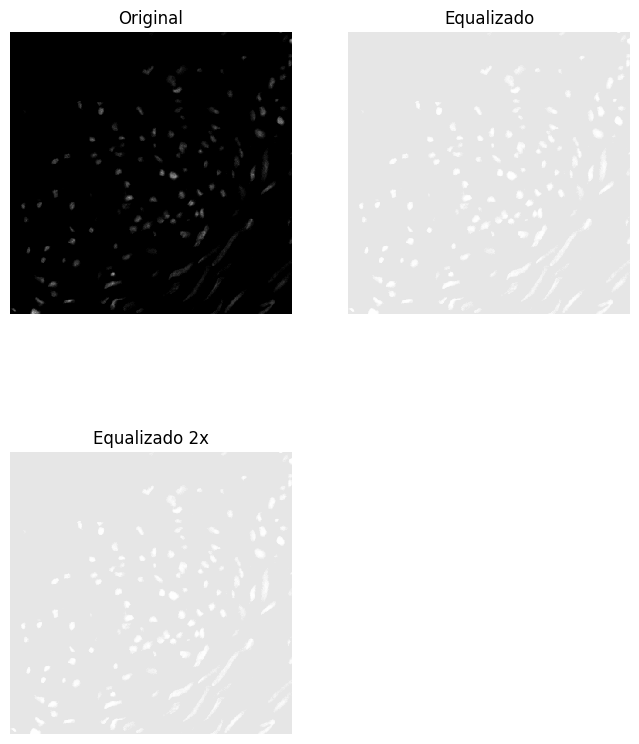

In [11]:
# code here

img3 = cv2.imread("im_cells.png", cv2.IMREAD_GRAYSCALE)

# 1° equalização

mapa = np.zeros(256, dtype=np.int64)

for pixel in img3.flatten():
    mapa[pixel] += 1

# CDF
total = mapa.sum()
cdf = np.cumsum(mapa) / total


# MAPEAMENTO
novos_niveis = np.floor(255 * cdf).astype(np.uint8)

img4 = novos_niveis[img3]

# 2° equalização

mapa = np.zeros(256, dtype=np.int64)

for pixel in img4.flatten():
    mapa[pixel] += 1

# CDF
total = mapa.sum()
cdf = np.cumsum(mapa) / total


# MAPEAMENTO
novos_niveis = np.floor(255 * cdf).astype(np.uint8)

img5 = novos_niveis[img4]

plt.figure(figsize=(8,10))

plt.subplot(2,2,1)
plt.imshow(img3, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title('Original')
plt.axis('off')


plt.subplot(2,2,2)
plt.imshow(img4, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title('Equalizado')
plt.axis('off')


plt.subplot(2,2,3)
plt.imshow(img5, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title('Equalizado 2x')
plt.axis('off')